In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/jax-f16-gcas-validation

/content/drive/MyDrive/jax-f16-gcas-validation


In [ ]:
!pip install jaxlib
!pip install jax_f16

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 4.3 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade jax[cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 12.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [ ]:
import scipy as sp
from jax.scipy.stats.multivariate_normal import logpdf as multivar_gauss_logpdf


In [ ]:
from simulate import *
from f16system import *
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import gc

In [ ]:
system = F16System(T=300)
nominal_mean = system.noise_mean
nominal_std = system.noise_std
# p = (nominal_mean, nominal_cov)

In [ ]:
# def generate_proposal_distributions(p_mean, p_std, num_proposals=1, mean_scale=1, std_scale=1):
#     """
#     generate proposal distributions by taking the nominal distribution
#     parameters and perturbing them by a random value
#     """
#     qs = [] # proposal distributions
#     mask = np.zeros(16) # which components we are going to change for proposal
#     mask[3] = 1
#     mask[6] = 1
#     # create proposal distributions by slightly perturbing the parameters of nominal dist
#     for i in range(num_proposals):
#         # use mask to only change the noisy features
#         q_mean = p_mean + (mean_scale * np.random.randn(16) * mask)
#         q_std = p_std + (std_scale * np.random.randn(16) * mask)
#         # qs.append(jsp.stats.multivariate_normal(q_mean, system.noise_std))
#         qs.append((q_mean, q_std))
#     return qs

In [ ]:
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=50, mean_scale=5e-4, std_scale=1e-2)

In [ ]:
# x = [q[0][3] for q in qs]
# y = [q[0][6] for q in qs]
# plt.scatter(x, y)

In [ ]:
def generate_proposal_distributions(p_mean, p_std, num_proposals=1, mean_scale=1, std_scale=1):
    """
    generate proposal distributions by taking the nominal distribution
    parameters and perturbing them by a random value
    """
    qs = [] # proposal distributions
    mask = np.zeros(16) # which components we are going to change for proposal
    mask[3] = 1
    mask[6] = 1
    # create proposal distributions by slightly perturbing the parameters of nominal dist
    for i in range(num_proposals):
        # use mask to only change the noisy features
        q_mean = p_mean + (mean_scale * np.random.uniform(-1, 1, 16) * mask)
        q_std = p_std + (std_scale * np.random.uniform(0, 1, 16) * mask)
        # qs.append(jsp.stats.multivariate_normal(q_mean, system.noise_std))
        qs.append((q_mean, q_std))
    return qs

In [ ]:
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.6508633e-05,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-03,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.0508633e-05,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-03,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.0508633e-06,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-04,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.099e-02, 1.e-10, 1.e-10, 1.099e-02, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]

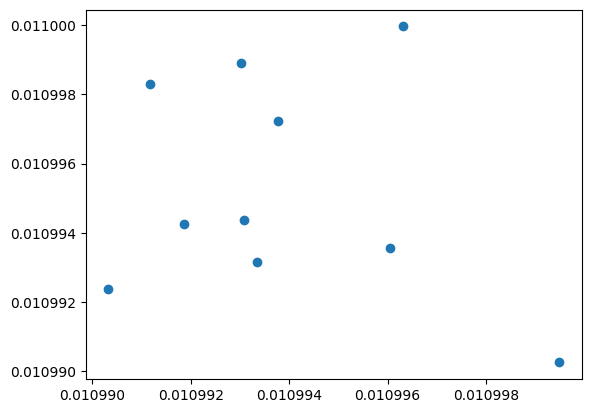

In [ ]:
qs = generate_proposal_distributions(proposal[0][0], proposal[0][1], num_proposals=10, mean_scale=1e-8, std_scale=1e-5)
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=70, mean_scale=5e-2, std_scale=1e-4)
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=50, mean_scale=1e-3, std_scale=0)
x = [q[1][3] for q in qs]
y = [q[1][6] for q in qs]
plt.scatter(x, y)

In [ ]:
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=30, mean_scale=0, std_scale=1e-2)
# x = [q[0][3] for q in qs]
# y = [q[0][6] for q in qs]
# plt.scatter(x, y)

In [ ]:
# print(qs)
qs_plus = qs + proposal

In [ ]:
def imp_sampl_fail_est(p, qs, num_rollouts, DMMIS=False):
    q_systems = []
    for q in qs:
        q_system = F16System(T=300, prop_noise_mean=q[0], prop_noise_std=q[1])
        q_systems.append(q_system)
    rollouts = []
    ws = []
    weighted_sum = 0
    rollout_cnt = 0
    estimates = []
    for j in tqdm(range(num_rollouts), desc="Running Rollouts"):
        for q in q_systems:
            rollout_cnt += 1
            rollout = q.rollout_min_altitude_and_loglik()
            gc.collect()
            rollouts.append(rollout)
            traj = rollout[2][2].reshape(-1, 16)
            p_i = gaussian_log_pdf_traj(traj, p.noise_mean, p.noise_cov)
            q_i = gaussian_log_pdf_traj(traj, q.sensor.mean, q.sensor.cov)
            # ws.append(np.exp(p_i - q_i))
            w_i = np.exp(p_i - q_i)
            if rollout[0] < CRASH_ALT:
                print("\nFound failure!")
                print(p_i)
                print(q_i)
                print("Weight is", w_i.item())
                weighted_sum += w_i.item()
            est = weighted_sum / rollout_cnt
            print("\nWeighted sum:", weighted_sum)
            print("\nFailure probability estimate after %d rollouts: %f" % (rollout_cnt, est))
            estimates.append(est)
        jax.clear_caches()
    return estimates

In [ ]:
estimates = imp_sampl_fail_est(system, qs, num_rollouts=20)

Running Rollouts:   0%|          | 0/20 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 3 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 4 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 5 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 6 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 7 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 8 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 9 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 10 rollouts: 0.000000


Running Rollouts:   5%|▌         | 1/20 [02:09<41:08, 129.93s/it]


Weighted sum: 0

Failure probability estimate after 11 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 12 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 13 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 14 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 15 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 16 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 17 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 18 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 19 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 20 rollouts: 0.000000


Running Rollouts:  10%|█         | 2/20 [04:22<39:28, 131.61s/it]

...

Running Rollouts:  90%|█████████ | 18/20 [40:22<04:33, 136.58s/it]


Weighted sum: 61.57795075191825

Failure probability estimate after 181 rollouts: 0.340210

Weighted sum: 61.57795075191825

Failure probability estimate after 182 rollouts: 0.338340

Weighted sum: 61.57795075191825

Failure probability estimate after 183 rollouts: 0.336492

Weighted sum: 61.57795075191825

Failure probability estimate after 184 rollouts: 0.334663

Weighted sum: 61.57795075191825

Failure probability estimate after 185 rollouts: 0.332854

Weighted sum: 61.57795075191825

Failure probability estimate after 186 rollouts: 0.331064

Weighted sum: 61.57795075191825

Failure probability estimate after 187 rollouts: 0.329294

Weighted sum: 61.57795075191825

Failure probability estimate after 188 rollouts: 0.327542

Weighted sum: 61.57795075191825

Failure probability estimate after 189 rollouts: 0.325809

Weighted sum: 61.57795075191825

Failure probability estimate after 190 rollouts: 0.324094


Running Rollouts:  95%|█████████▌| 19/20 [42:38<02:16, 136.57s/it]


Weighted sum: 61.57795075191825

Failure probability estimate after 191 rollouts: 0.322398

Weighted sum: 61.57795075191825

Failure probability estimate after 192 rollouts: 0.320718

Weighted sum: 61.57795075191825

Failure probability estimate after 193 rollouts: 0.319057

Weighted sum: 61.57795075191825

Failure probability estimate after 194 rollouts: 0.317412

Weighted sum: 61.57795075191825

Failure probability estimate after 195 rollouts: 0.315784

Weighted sum: 61.57795075191825

Failure probability estimate after 196 rollouts: 0.314173

Weighted sum: 61.57795075191825

Failure probability estimate after 197 rollouts: 0.312578

Weighted sum: 61.57795075191825

Failure probability estimate after 198 rollouts: 0.311000

Weighted sum: 61.57795075191825

Failure probability estimate after 199 rollouts: 0.309437

Weighted sum: 61.57795075191825

Failure probability estimate after 200 rollouts: 0.307890


Running Rollouts: 100%|██████████| 20/20 [44:56<00:00, 134.80s/it]


In [ ]:
# estimates = imp_sampl_fail_est(system, proposal, num_rollouts=100)

In [ ]:
# prob = [estimates[i] / (i+1) for i in range(len(estimates))]    # accidentally

Text(0, 0.5, 'Probability estimate')

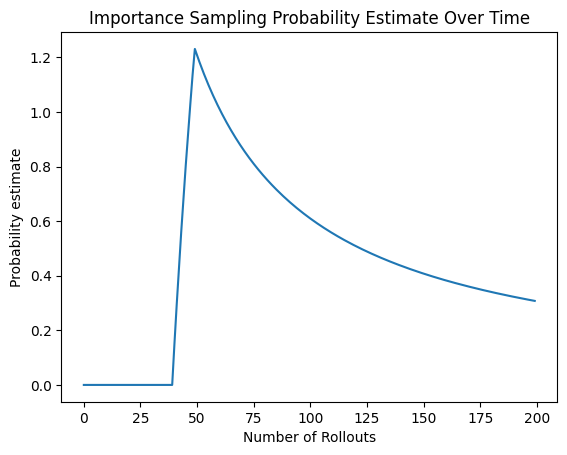

In [ ]:
plt.plot(np.arange(len(estimates)), estimates)
plt.title("Importance Sampling Probability Estimate Over Time")
plt.xlabel("Number of Rollouts")
plt.ylabel("Probability estimate")